  + AverageTemperature: 25.0
  + AverageTemperatureUncertainty: 0.5

Significa que la temperatura real ese mes probablemente estuvo entre 24.5°C y 25.5°C.

In [2]:
import numpy as np 
import pandas as pd

In [3]:
## Puede un otoño predecir una primavera? o cualquier otra estacion?

In [4]:
df = pd.read_csv('../data/GlobalLandTemperaturesByCity.csv', parse_dates = ['dt'], index_col = 'dt')

In [5]:
df.rename(columns={'AverageTemperature': 'AvTemp', 'AverageTemperatureUncertainty': 'AvTempUn', 'Country': 'country'}, inplace=True)
df

,AvTemp,AvTempUn,City,country,Latitude,Longitude
dt,,,,,,
1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
...,...,...,...,...,...,...
2013-05-01,11.464,0.236,Zwolle,Netherlands,52.24N,5.26E
2013-06-01,15.043,0.261,Zwolle,Netherlands,52.24N,5.26E
2013-07-01,18.775,0.193,Zwolle,Netherlands,52.24N,5.26E


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8599212 entries, 1743-11-01 to 2013-09-01
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   AvTemp     float64
 1   AvTempUn   float64
 2   City       object 
 3   country    object 
 4   Latitude   object 
 5   Longitude  object 
dtypes: float64(2), object(4)
memory usage: 459.2+ MB


In [7]:
def interpolar_anual(grupo):
    ''' Definir la función que calcula la media de los vecinos anuales'''
    anterior = grupo.shift(12)
    siguiente = grupo.shift(-12)
    
    media_vecinos = (anterior + siguiente) / 2
    
    # Solo rellena donde hay NaN, manteniendo los valores originales si existen
    return grupo.fillna(media_vecinos)

df['AvTemp'] = df.groupby('country')['AvTemp'].transform(interpolar_anual)

In [8]:
df['AvTemp'] = df.groupby('country')['AvTemp'].transform(lambda x: x.interpolate(method='linear'))

In [9]:
df = df[(df.index >= '1819-01-01') & (df.index < '2013-01-01')]
df

,AvTemp,AvTempUn,City,country,Latitude,Longitude
dt,,,,,,
1819-01-01,2.380,3.491,Århus,Denmark,57.05N,10.33E
1819-02-01,0.859,3.962,Århus,Denmark,57.05N,10.33E
1819-03-01,2.397,8.171,Århus,Denmark,57.05N,10.33E
1819-04-01,6.396,1.717,Århus,Denmark,57.05N,10.33E
1819-05-01,11.834,2.006,Århus,Denmark,57.05N,10.33E
...,...,...,...,...,...,...
2012-08-01,18.588,0.224,Zwolle,Netherlands,52.24N,5.26E
2012-09-01,14.333,0.207,Zwolle,Netherlands,52.24N,5.26E
2012-10-01,10.358,0.208,Zwolle,Netherlands,52.24N,5.26E


In [10]:
df['country'] = df['country'].replace({'Côte D\'Ivoire': "Cote d'Ivoire",
                                       'United States': "USA",
                                       "Congo (Democratic Republic Of The)": 'Congo',
                                       "Bosnia And Herzegovina": 'Bosnia and Herzegovina',
                                       'Guinea Bissau': 'Guinea-Bissau'})

C:\Users\Varushet\AppData\Local\Temp\ipykernel_15312\3292596309.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['country'] = df['country'].replace({'Côte D\'Ivoire': "Cote d'Ivoire",


In [11]:
df['numero'] = df['Latitude'].str.extract(r'([0-9]+\.[0-9]{2})').astype(float)
df['OrLat'] = df['Latitude'].str.extract(r'([NS])$')

C:\Users\Varushet\AppData\Local\Temp\ipykernel_15312\1537631586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['numero'] = df['Latitude'].str.extract(r'([0-9]+\.[0-9]{2})').astype(float)
C:\Users\Varushet\AppData\Local\Temp\ipykernel_15312\1537631586.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OrLat'] = df['Latitude'].str.extract(r'([NS])$')


In [12]:
df['Latitude'] = np.where(df['OrLat'] == 'S', -df['numero'], df['numero'])

C:\Users\Varushet\AppData\Local\Temp\ipykernel_15312\1216536586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Latitude'] = np.where(df['OrLat'] == 'S', -df['numero'], df['numero'])


In [13]:
df['numero'] = df['Longitude'].str.extract(r'([0-9]+\.[0-9]{2})').astype(float)
df['OrLon'] = df['Longitude'].str.extract(r'([EW])$')

C:\Users\Varushet\AppData\Local\Temp\ipykernel_15312\704299056.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['numero'] = df['Longitude'].str.extract(r'([0-9]+\.[0-9]{2})').astype(float)
C:\Users\Varushet\AppData\Local\Temp\ipykernel_15312\704299056.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OrLon'] = df['Longitude'].str.extract(r'([EW])$')


In [14]:
df['Longitude'] = np.where(df['OrLon'] == 'W', -df['numero'], df['numero'])

C:\Users\Varushet\AppData\Local\Temp\ipykernel_15312\954906886.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Longitude'] = np.where(df['OrLon'] == 'W', -df['numero'], df['numero'])


In [15]:
df = df.drop(columns=['numero', 'OrLat', 'OrLon', 'AvTempUn'])
df

,AvTemp,City,country,Latitude,Longitude
dt,,,,,
1819-01-01,2.380,Århus,Denmark,57.05,10.33
1819-02-01,0.859,Århus,Denmark,57.05,10.33
1819-03-01,2.397,Århus,Denmark,57.05,10.33
1819-04-01,6.396,Århus,Denmark,57.05,10.33
1819-05-01,11.834,Århus,Denmark,57.05,10.33
...,...,...,...,...,...
2012-08-01,18.588,Zwolle,Netherlands,52.24,5.26
2012-09-01,14.333,Zwolle,Netherlands,52.24,5.26
2012-10-01,10.358,Zwolle,Netherlands,52.24,5.26


In [16]:
df['year'] = df.index.year
df['month'] = df.index.month
df

,AvTemp,City,country,Latitude,Longitude,year,month
dt,,,,,,,
1819-01-01,2.380,Århus,Denmark,57.05,10.33,1819,1
1819-02-01,0.859,Århus,Denmark,57.05,10.33,1819,2
1819-03-01,2.397,Århus,Denmark,57.05,10.33,1819,3
1819-04-01,6.396,Århus,Denmark,57.05,10.33,1819,4
1819-05-01,11.834,Århus,Denmark,57.05,10.33,1819,5
...,...,...,...,...,...,...,...
2012-08-01,18.588,Zwolle,Netherlands,52.24,5.26,2012,8
2012-09-01,14.333,Zwolle,Netherlands,52.24,5.26,2012,9
2012-10-01,10.358,Zwolle,Netherlands,52.24,5.26,2012,10


In [17]:
df['Dist_to_Pole'] = 90 - df['Latitude'].abs()

In [18]:
luz = pd.read_csv('../data/df_luz_mensual.csv.gz')
luz

,country,month,sun_h
0,Afghanistan,1,10.15
1,Afghanistan,2,10.96
2,Afghanistan,3,11.98
3,Afghanistan,4,13.06
4,Afghanistan,5,14.00
...,...,...,...
2369,Гватемала,7,12.90
2370,Польша,7,16.17
2371,Турция,7,14.72
2372,كولومبيا,7,12.65


In [19]:
# df1: El pequeño con country, month, sun_h
# df2: El grande con Country, Month, AvTemp, etc.

# Asegúrate de que las columnas clave tengan el mismo nombre o especifícalas
df_unido = pd.merge(
    df.reset_index(),
    luz,          # Dataset con los datos a añadir (derecha)
    left_on=['country', 'month'], # Columnas en df2
    right_on=['country', 'month'], # Columnas en df1
    how='left'    # 'left' mantiene todos los datos del df2, añadiendo sun_h si hay coincidencia
).set_index('dt')

# Eliminar columnas duplicadas si se crearon (opcional, para limpiar)
# df_unido.drop(columns=['country', 'month'], inplace=True) 

In [20]:
print(df_unido.isnull().sum())

AvTemp          0
City            0
country         0
Latitude        0
Longitude       0
year            0
month           0
Dist_to_Pole    0
sun_h           0
dtype: int64


In [21]:
#LOS DATOS DE LA LISTA paises NO VAN A SER FIABLES para el siglo XIX
paises = ['Madagascar', 'Mauritius']
for p in paises:
    mask_p = df_unido['country'] == p
    medias_mes_p = df_unido.loc[mask_p].groupby('month')['AvTemp'].mean()
    print(p, medias_mes_p)
    
    mask_null_p = mask_p & df_unido['AvTemp'].isnull()
    # print(mask_null_p)
    df_unido.loc[mask_null_p, 'AvTemp'] = df_unido.loc[mask_null_p, 'month'].map(medias_mes_p)


Madagascar month
1     23.844552
2     23.892672
3     23.760411
4     22.975514
5     21.802167
6     20.537758
7     20.053300
8     20.374889
9     21.279753
10    22.310292
11    23.303155
12    23.622851
Name: AvTemp, dtype: float64
Mauritius month
1     25.542853
2     25.636128
3     25.435815
4     24.701357
5     23.691993
6     22.608332
7     22.072001
8     21.964584
9     22.320416
10    22.945644
11    24.067547
12    24.998113
Name: AvTemp, dtype: float64


### 📋 Muestra

,AvTemp,City,country,Latitude,Longitude,year,month,Dist_to_Pole,sun_h
dt,,,,,,,,,
1819-01-01,2.380,Århus,Denmark,57.05,10.33,1819,1,32.95,7.79
1819-02-01,0.859,Århus,Denmark,57.05,10.33,1819,2,32.95,9.65
1819-03-01,2.397,Århus,Denmark,57.05,10.33,1819,3,32.95,11.89
1819-04-01,6.396,Århus,Denmark,57.05,10.33,1819,4,32.95,14.21
1819-05-01,11.834,Århus,Denmark,57.05,10.33,1819,5,32.95,16.36


### 📊 Info → `7,699,159` filas × `9` columnas

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7699159 entries, 1819-01-01 to 2012-12-01
Data columns (total 9 columns):
 #   Column        Dtype  
---  ------        -----  
 0   AvTemp        float64
 1   City          object 
 2   country       object 
 3   Latitude      float64
 4   Longitude     float64
 5   year          int32  
 6   month         int32  
 7   Dist_to_Pole  float64
 8   sun_h         float64
dtypes: float64(5), int32(2), object(2)
memory usage: 528.7+ MB
None


#### Uniques

AvTemp          195265
City              3448
country            158
Latitude            73
Longitude         1227
year               194
month               12
Dist_to_Pole        43
sun_h              667
dtype: int64


### ⚠️ Null & NaN

AvTemp          0
City            0
country         0
Latitude        0
Longitude       0
year            0
month           0
Dist_to_Pole    0
sun_h           0
dtype: int64


### 📦 Describe

,AvTemp,Latitude,Longitude,year,month,Dist_to_Pole,sun_h
count,7699159.000,7699159.000,7699159.000,7699159.000,7699159.000,7699159.000,7699159.000
mean,17.409,23.748,32.425,1920.583,6.501,60.557,12.181
std,10.162,22.991,74.065,53.613,3.452,15.022,1.847
min,-42.704,-52.240,-151.130,1819.000,1.000,20.080,4.560
25%,11.541,10.450,-6.390,1875.000,4.000,49.010,11.110
50%,19.779,28.130,36.610,1921.000,7.000,60.260,12.110
75%,25.500,40.990,98.840,1967.000,10.000,71.520,13.260
max,39.153,69.920,176.950,2012.000,12.000,89.200,20.030


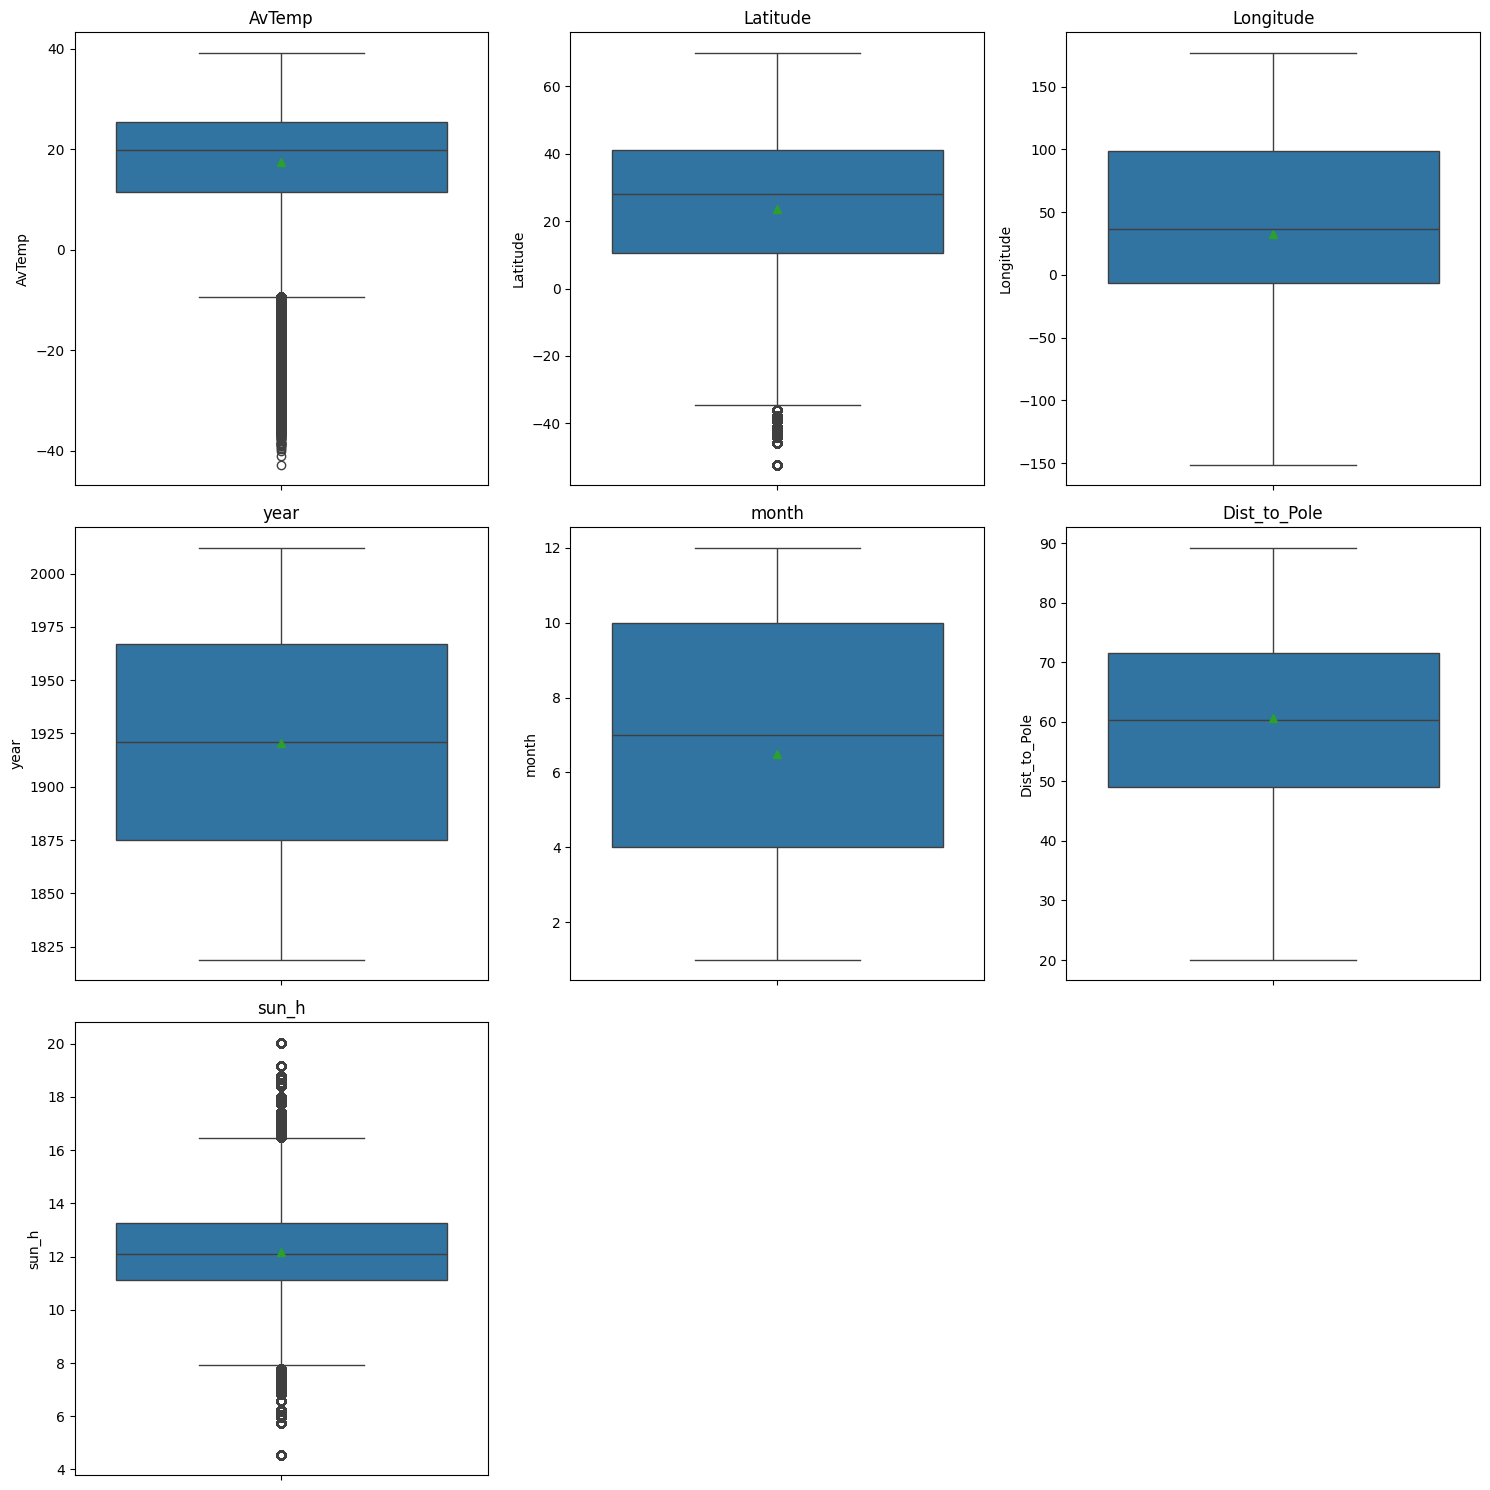

### 📈 Comparación

### (target: AvTemp)

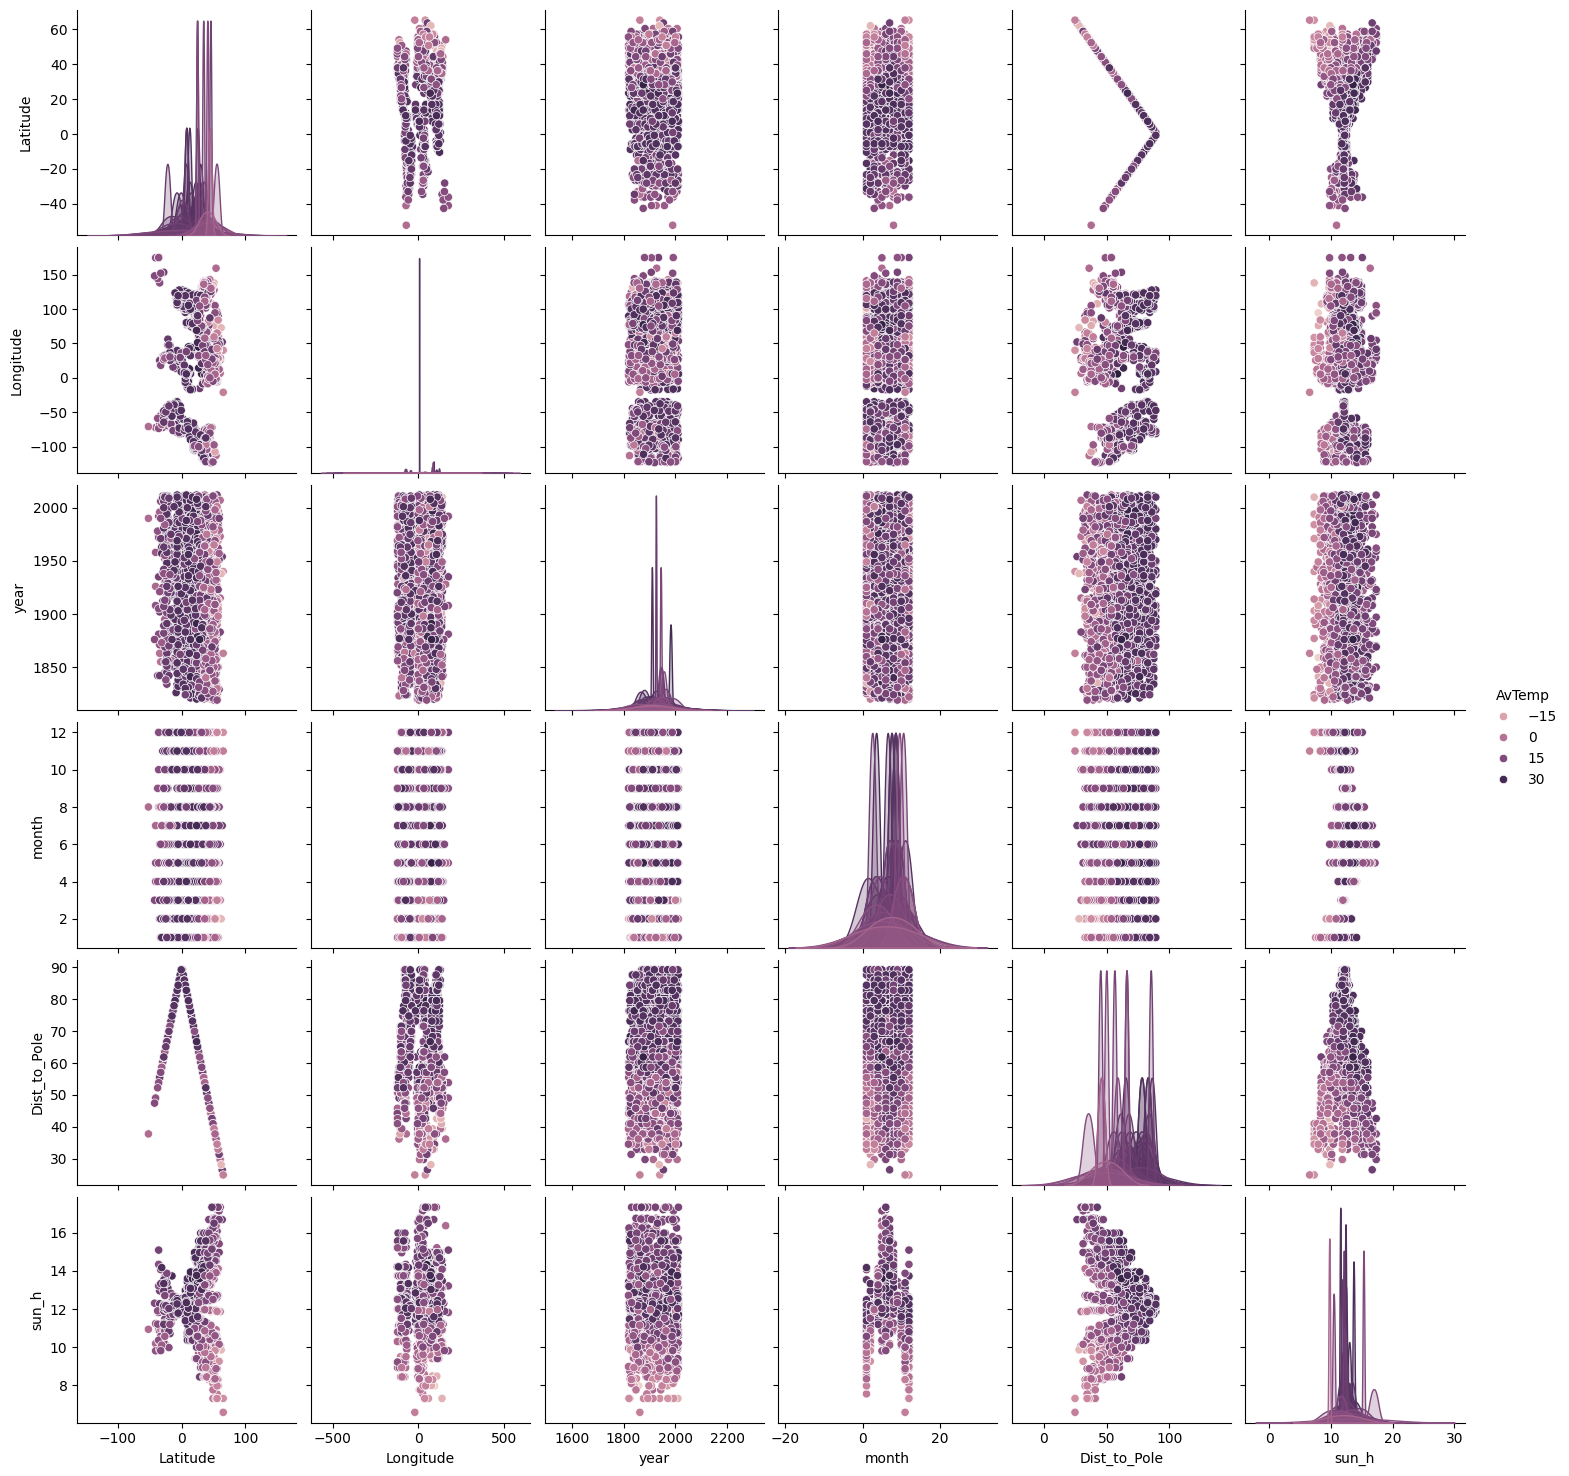

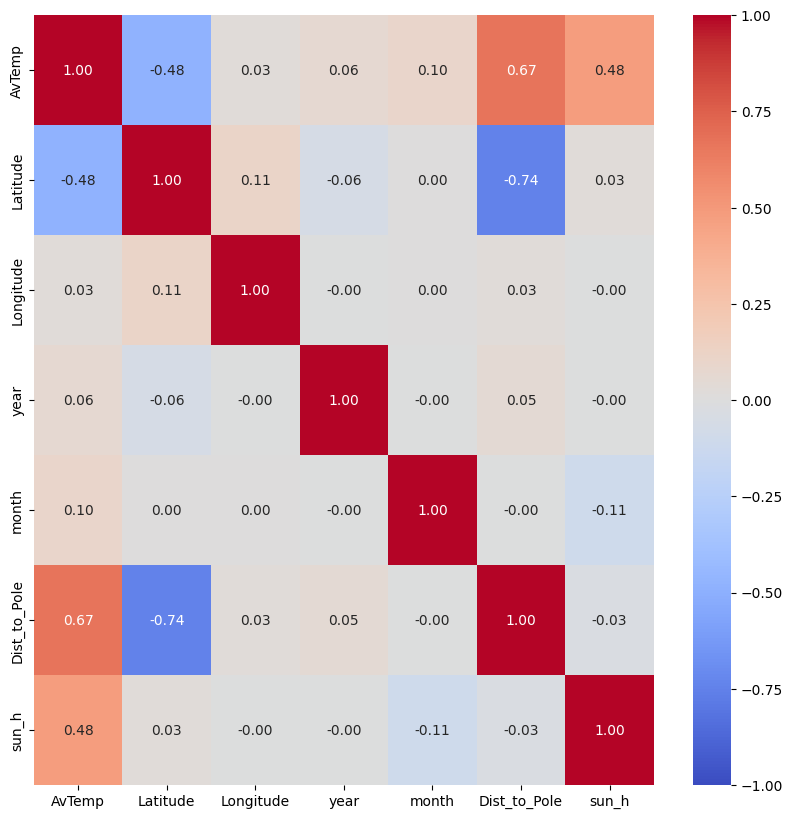

In [24]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

def eda(df, target=None):
    """
        Realiza un EDA automático visual.
    """
    
    # 1. MUESTRA
    print('='*100)
    display(Markdown("### 📋 Muestra"))
    display(df.head()) # Head es suficiente y más rápido
    
    # 2. INFO
    print('='*100)
    display(Markdown(f"### 📊 Info → `{df.shape[0]:,}` filas × `{df.shape[1]}` columnas"))
    # df.info() puede ser muy lento en consola, mejor mostrar dtypes resumidos si es gigante
    # Pero lo dejo como pediste:
    print(df.info())
    display(Markdown('#### Uniques'))
    print(df.nunique())
    
    # 3. NULOS
    print('='*100)
    display(Markdown("### ⚠️ Null & NaN"))
    print(df.isna().sum())
    # Mostrar solo las filas con nulos si no son demasiadas, para no colgar el notebook
    null_rows = df[df.isnull().any(axis=1)]
    if len(null_rows) > 0:
        display(null_rows.head())
    
    # 4. BOXPLOTS (Solo numéricas)
    print('='*100)
    display(Markdown("### 📦 Describe"))
    display(df.describe().round(3))
    
    cols = df.describe().columns
    n = len(cols)

    if n > 0:
        # Crear rejilla
        fig, axes = plt.subplots(nrows=(n//3)+1, ncols=3, figsize=(15, 5*((n//3)+1)))
        axes = axes.flatten()

        for i, col in enumerate(cols):
            sns.boxplot(y=df[col], ax=axes[i], showmeans=True)
            axes[i].set_title(col)

        # Limpiar gráficos vacíos sobrantes
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
            
        plt.tight_layout()
        plt.show()
    
    # 5. PAIRPLOT
    print('='*100)
    display(Markdown(f"### 📈 Comparación"))
    
    df_for_plot = df.sample(min(2000, len(df))) if len(df) > 2000 else df

    if target is not None:
        t_name = target.name if hasattr(target, 'name') else target
        display(Markdown(f"### (target: {t_name})"))
        
        if t_name not in df_for_plot.columns:
            # CAMBIO CLAVE: .copy() para evitar SettingWithCopyWarning y alineación lenta
            df_plot = df_for_plot[cols].copy()
            df_plot[t_name] = target.loc[df_plot.index] if hasattr(target, 'loc') else target
        else:
            df_plot = df_for_plot[cols]

        # Si el target no está en cols, lo añadimos al plot manualmente si es necesario
        if t_name not in df_plot.columns:
             df_plot[t_name] = df_for_plot[t_name]

        sns.pairplot(df_plot, hue=t_name)
        plt.show()
        
    else:
        sns.pairplot(df_for_plot)
        plt.show()
        
    # HEATMAP
    if n > 1:
        plt.figure(figsize=(10, 10)) 
        # CAMBIO CLAVE: fmt='.2f' es correcto para correlaciones (-1 a 1). '.1%' da error.
        sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', vmin=-1, vmax=1, cmap="coolwarm")
        plt.show()
        
eda(df_unido, df_unido['AvTemp'])

In [23]:
df_unido.to_csv('../data/tiempoDS.csv.gz', index=False, compression='gzip')